**DATASET SUMMARY SCRIPT**

This is a script aiming to transmit an intuitive understanding of the dataset that we are wporking with here. Classes, class sizes, and example images are introduced here, as well as some challenges that may arise from this data set.



**Libraries**

In [ ]:
import os
import matplotlib.pyplot as plt
import random
from glob import glob
from PIL import Image

**Introduction: Training Data**

In [ ]:
base_dir = os.getcwd()  # current working directory
training = os.path.join(base_dir, "train")
training_classes = [d for d in os.listdir(training) if os.path.isdir(os.path.join(training, d))]

print(training_classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


The training data consists out of seven classes of images, each displaying one out of seven emootions. 
How is this data distributed?

In [ ]:
for cls in training_classes:  # loop over the list of class folders
    class_path = os.path.join(training, cls)  # join base path with folder name
    images = glob(os.path.join(class_path, '*.jpg'))
    print(f"Class '{cls}': {len(images)} images")

Class 'angry': 3995 images
Class 'disgust': 436 images
Class 'fear': 4097 images
Class 'happy': 7215 images
Class 'neutral': 4965 images
Class 'sad': 4830 images
Class 'surprise': 3171 images


The data is greatly uneven distributed, with the extremes being the "happy" class (>7200 images), and the "disgust class (<450 images).

Let´s take a look at some of those images: 

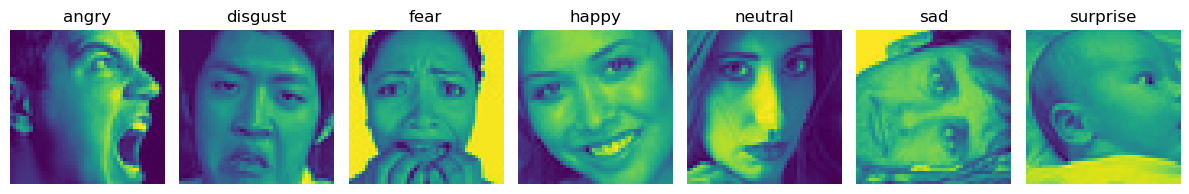

In [ ]:
plt.figure(figsize=(12, 6))

for i, cls in enumerate(training_classes):
    class_path = os.path.join(training, cls)
    images = glob(os.path.join(class_path, '*.jpg'))
    sample_img_path = random.choice(images)  # pick one random image
    img = Image.open(sample_img_path)
    
    plt.subplot(1, 7, i+1)  # arrange in 2 rows, 4 columns
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

**Challenges**

The data imbalance between the classes could lead to the model performing worse on classification of minority classes (such as disgust) and predicting major classes more often, simply because more training data is available. However, if the images are not similarly distributed in the test set, then the assumption that, imply because something is occuring often in the training data, it will be likely to be the case for the test data as well, will notacibly impact the models performance. 
Let´s check out the data distribution in the test data:

In [13]:
base_dir = os.getcwd()  # current working directory
testing = os.path.join(base_dir, "test")
testing_classes = [d for d in os.listdir(testing) if os.path.isdir(os.path.join(testing, d))]

print(testing_classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


The classes in the test datset are the same as in the training dataset. What about the quantity distrubtion?

In [14]:
for cls in testing_classes:  # loop over the list of class folders
    class_path = os.path.join(testing, cls)  # join base path with folder name
    images = glob(os.path.join(class_path, '*.jpg'))
    print(f"Class '{cls}': {len(images)} images")

Class 'angry': 958 images
Class 'disgust': 111 images
Class 'fear': 1024 images
Class 'happy': 1774 images
Class 'neutral': 1233 images
Class 'sad': 1247 images
Class 'surprise': 831 images


The class imbalance in the train set is reflected in the test dataset. This means that the evaluation is taking into account "real-world" frequencies. However, a high accuracy in the model may be misleading because it might be achieved by estimating frequencies rather than truly understanding the respective properties of a facial expression, especially for rarely represented classes such as "disgust". 